In [ ]:
import tensorflow as tf
import visualkeras
from PIL import ImageFont

# Build model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,), name="Input"),
    tf.keras.layers.Dense(128, activation="relu", name="Hidden_1"),
    tf.keras.layers.Dense(64, activation="relu", name="Hidden_2"),
    tf.keras.layers.Dense(32, activation="relu", name="Hidden_3"),
    tf.keras.layers.Dense(10, activation="softmax", name="Output")
])

# Optional font
font = ImageFont.load_default()

# Generate neural network diagram
visualkeras.layered_view(
    model,
    legend=True,
    font=font,
    spacing=30,
    scale_xy=15,
    scale_z=2,
    max_z=100
).show()

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\visualkeras\layered.py:231: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


AttributeError: 'Dense' object has no attribute 'output_shape'

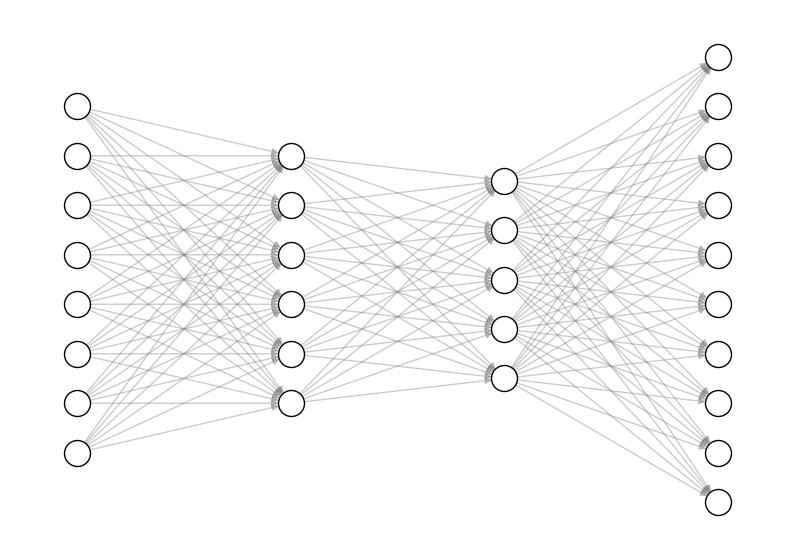

In [1]:
import matplotlib.pyplot as plt
import networkx as nx

layers = [8, 6, 5, 10]

G = nx.DiGraph()
pos = {}

x = 0
for i, layer in enumerate(layers):
    y_offset = -(layer - 1) / 2
    for j in range(layer):
        node = f"L{i}_{j}"
        G.add_node(node)
        pos[node] = (x, y_offset + j)

        if i > 0:
            for k in range(layers[i - 1]):
                G.add_edge(f"L{i-1}_{k}", node)

    x += 2

plt.figure(figsize=(10,7))
nx.draw_networkx_edges(G, pos, edge_color="gray", alpha=0.4)
nx.draw_networkx_nodes(
    G,
    pos,
    node_color="white",
    edgecolors="black",
    node_size=350
)

plt.axis("off")
plt.show()

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


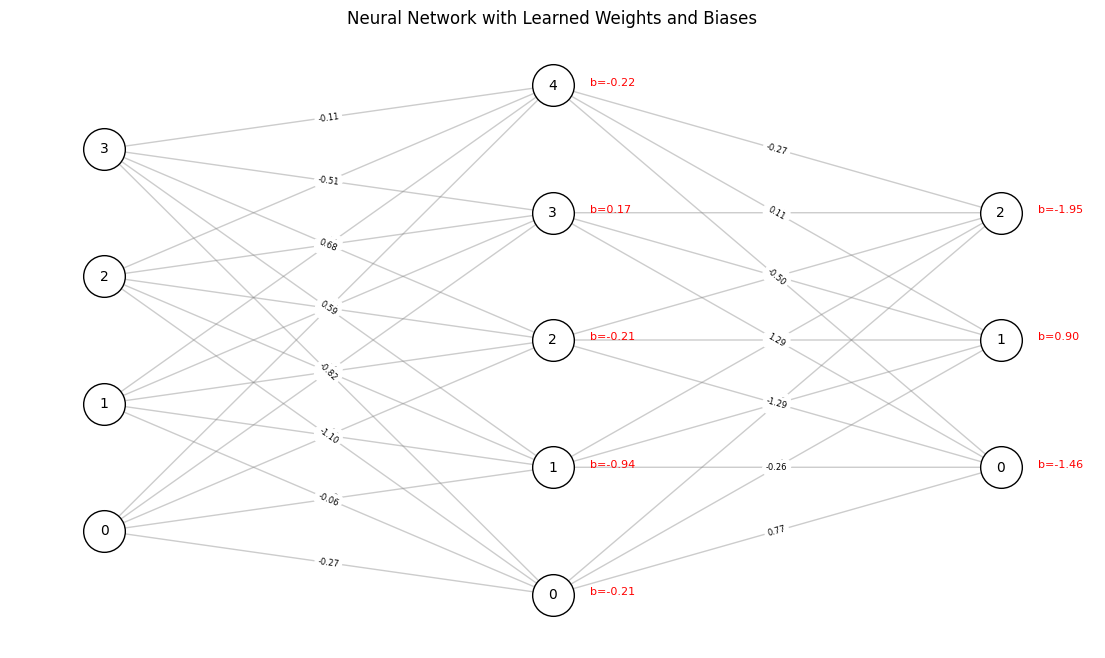

Accuracy: 1.0


In [3]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

# -----------------------------
# Load Dataset
# -----------------------------
iris = load_iris()
X = iris.data
y = iris.target

# Standardize
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Train Neural Network
# -----------------------------
model = MLPClassifier(
    hidden_layer_sizes=(5,),
    activation='relu',
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

# -----------------------------
# Extract Weights and Biases
# -----------------------------
weights = model.coefs_
biases = model.intercepts_

layers = [4, 5, 3]      # Input, Hidden, Output

G = nx.DiGraph()
pos = {}

x_gap = 3

# Create nodes
for i, layer_size in enumerate(layers):

    y_offset = -(layer_size-1)/2

    for j in range(layer_size):

        node = f"L{i}_{j}"

        G.add_node(node)

        pos[node] = (i*x_gap, y_offset+j)

# Create edges with weights
edge_labels = {}

for l in range(len(weights)):

    W = weights[l]

    for i in range(W.shape[0]):
        for j in range(W.shape[1]):

            n1 = f"L{l}_{i}"
            n2 = f"L{l+1}_{j}"

            G.add_edge(n1, n2)

            edge_labels[(n1,n2)] = f"{W[i,j]:.2f}"

# -----------------------------
# Draw
# -----------------------------
plt.figure(figsize=(14,8))

nx.draw_networkx_edges(
    G,
    pos,
    edge_color="gray",
    alpha=0.4
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_color="white",
    edgecolors="black",
    node_size=900
)

# Node labels
node_labels = {}

for node in G.nodes():
    node_labels[node] = node.split("_")[1]

nx.draw_networkx_labels(
    G,
    pos,
    labels=node_labels,
    font_size=10
)

# Edge labels (Weights)
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=6
)

# Bias labels
for l, b in enumerate(biases):

    for j, bias in enumerate(b):

        node = f"L{l+1}_{j}"

        x, y = pos[node]

        plt.text(
            x+0.25,
            y,
            f"b={bias:.2f}",
            fontsize=8,
            color="red"
        )

plt.title("Neural Network with Learned Weights and Biases")
plt.axis("off")
plt.show()

print("Accuracy:", model.score(X_test, y_test))

In [1]:
from nilearn import datasets

stat_img = datasets.load_sample_motor_activation_image()

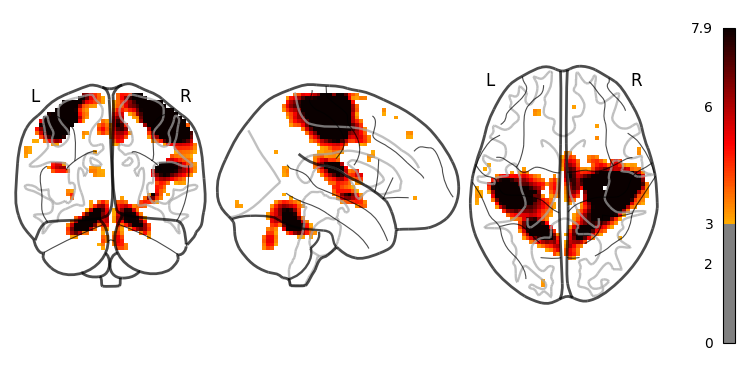

In [2]:
from nilearn import plotting

plotting.plot_glass_brain(stat_img, threshold=3)

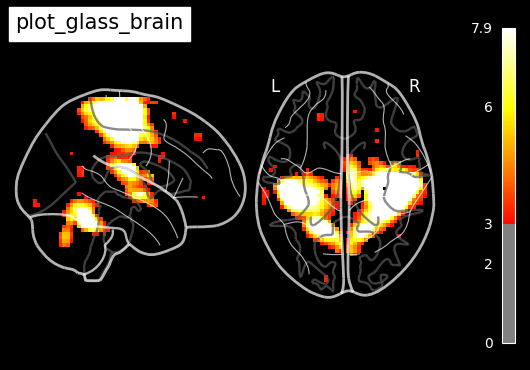

In [3]:
plotting.plot_glass_brain(
    stat_img,
    title="plot_glass_brain",
    black_bg=True,
    display_mode="xz",
    threshold=3,
)